## 1. Định nghĩa Vấn đề
**Mô tả**
Bộ dữ liệu housing (Boston-style) gồm các mẫu đại diện cho các khu vực địa phương; mỗi mẫu chứa các đặc trưng về điều kiện kinh tế, hạ tầng và đặc tính nhà ở. Mục tiêu là dự đoán giá nhà trung vị của từng khu vực dựa trên các đặc trưng này. File dữ liệu trong dự án: housing.csv.
**Dữ liệu vào (Features)**

+ CRIM — Tỷ lệ tội phạm theo khu vực
+ ZN — Tỷ lệ đất dành cho khu dân cư >25.000 sq.ft
+ INDUS — Tỷ lệ diện tích thương mại/phi bán lẻ (%)
+ CHAS — Biến chỉ số sông Charles (1 nếu giáp sông, 0 nếu không)
+ NOX — Nồng độ NOx (phần triệu)
+ RM — Số phòng trung bình trên mỗi cư trú
+ AGE — Tỷ lệ nhà xây trước năm 1940 (%)
+ DIS — Khoảng cách đến các trung tâm lao động (trọng số)
+ RAD — Chỉ số tiếp cận đường vành đai/xa lộ
+ TAX — Thuế tài sản hàng năm (trên 10.000$)
+ PTRATIO — Tỉ lệ học sinh/giáo viên
+ B — 1000(Bk - 0.63)^2 (chỉ số dân cư)
+ LSTAT — % dân có thu nhập thấp

**Kết quả / Mục tiêu (Target / Goal)**

+ MEDV — Giá nhà trung vị (median value) — bài toán hồi quy (dự đoán giá liên tục).

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1 Khai báo thư viện (Load Libraries)

In [16]:
# Load libraries
import numpy
import pandas as pd
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

### 2.2 Nạp dữ liệu (Load Dataset)

In [17]:
# Load dataset
filename = '../data/raw/housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
'B', 'LSTAT', 'MEDV']
dataset = pd.read_csv(filename, names=names, index_col=0)

##  

In [18]:
# Split-out validation dataset
array = dataset.values
X = array[:,0:13]
Y = array[:,13]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

Việc tách một tập kiểm định riêng (validation hold-out set) là cần thiết nhằm đánh giá khách quan hiệu quả của mô hình. Cụ thể, 80% dữ liệu được sử dụng cho quá trình huấn luyện và 20% còn lại được giữ lại để kiểm định. Cách tiếp cận này giúp xác nhận độ chính xác của mô hình trên dữ liệu chưa được nhìn thấy, đồng thời đảm bảo tính tin cậy và khả năng tổng quát của kết quả

In [19]:
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'neg_mean_squared_error'

Để đánh giá, hệ thống kiểm thử sẽ được thiết kế với 10-fold cross validation, một cấu hình tiêu chuẩn phù hợp cho tập dữ liệu có kích thước trung bình. Thuật toán sẽ được so sánh dựa trên chỉ số Mean Squared Error (MSE), nhằm phản ánh mức độ sai lệch trung bình của các dự đoán (với giá trị 0 biểu thị độ chính xác tuyệt đối).

In [20]:
# Spot-Check Algorithms
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

Để thiết lập mức hiệu suất cơ bản cho bài toán, tiến hành đánh giá thử (spot-check) nhiều thuật toán khác nhau phù hợp với bài toán hồi quy. Bộ thuật toán được lựa chọn bao gồm sáu mô hình đại diện:
– Thuật toán tuyến tính: Linear Regression (LR), Lasso Regression (LASSO) và ElasticNet (EN).
– Thuật toán phi tuyến: Classification and Regression Trees (CART), Support Vector Regression (SVR) và k-Nearest Neighbors (KNN).

In [21]:
# evaluate each model in turn
results = []
names = []
for name, model in models:
    try:
        # Bật shuffle=True để random_state có hiệu lực và tránh ValueError
        kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)
    except Exception as e:
        print(f"Error evaluating {name}: {e}")
        import traceback
        traceback.print_exc()


LR: -22.006009 (12.188886)
LASSO: -27.105803 (13.165915)
EN: -27.923014 (13.156405)
KNN: -39.808936 (16.507968)
CART: -27.172509 (16.977222)
SVR: -67.824705 (32.801530)


Kết quả cho thấy Linear Regression (LR) đạt giá trị MSE thấp nhất, thể hiện hiệu suất dự đoán tốt nhất trong các mô hình được thử nghiệm, tiếp theo là CART với sai số trung bình bình phương chỉ nhỉnh hơn đôi chút.

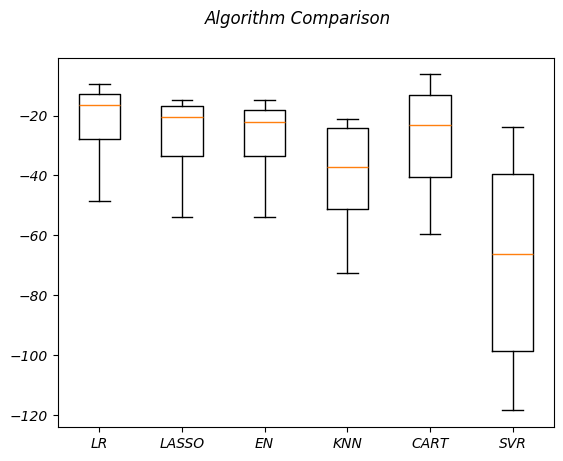

In [22]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

Sự khác biệt về thang đo giữa các thuộc tính có thể đang ảnh hưởng tiêu cực đến hiệu suất của tất cả các thuật toán, đặc biệt là SVR và KNN — vốn nhạy cảm với quy mô dữ liệu. Trong phần tiếp theo, các thuật toán sẽ được chạy lại trên phiên bản dữ liệu đã được chuẩn hóa nhằm đánh giá mức cải thiện về độ chính xác.

In [23]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

from save_images import save_notebook_images, print_save_summary

# Lưu tất cả hình ảnh từ notebook
result = save_notebook_images("Evaluate Algorithms.ipynb", output_dir="images")

# In tóm tắt kết quả
print_save_summary(result)


 Hoàn tất: 2 hình ảnh được lưu
 Thư mục: c:\Users\ASUS\Documents\SGU_khai_pha_du_lieu_DDU1231\Thực hành\Housing_project\Evaluate_Algorithms\images
 Danh sách file:
   - images\Compare_Algorithms_01.png
   - images\Compare_Algorithms_02.png


## 4. Tóm tắt Kết quả và Lưu Model Tốt Nhất

In [31]:
# Tìm model tốt nhất từ cross-validation
print("\n" + "="*60)
print("BEST BASELINE MODEL FROM EVALUATION")
print("="*60)

best_idx = numpy.argmax([r.mean() for r in results])
best_name = names[best_idx]
best_rmse = -results[best_idx].mean()  # Convert từ neg_mse sang RMSE

print(f"Best Model: {best_name}")
print(f"Best CV RMSE: {best_rmse:.4f}")
print(f"Std Dev: {results[best_idx].std():.4f}")

# Lấy model từ models list
best_model = None
for name, model in models:
    if name == best_name:
        best_model = model
        break

# Chuẩn bị scaler và huấn luyện model tốt nhất
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)

if best_model is not None:
    best_model.fit(rescaledX, Y_train)
    print(f"\n Model {best_name} đã huấn luyện trên toàn bộ training set")
else:
    print(f" Không tìm thấy model: {best_name}")


BEST BASELINE MODEL FROM EVALUATION
Best Model: LR
Best CV RMSE: 22.0060
Std Dev: 12.1889

 Model LR đã huấn luyện trên toàn bộ training set


In [34]:
# Save best baseline model
import sys, os
from datetime import datetime
sys.path.insert(0, os.path.abspath("../src"))
from save_model import save_best_model

# Tạo thư mục exp với ngày và tên nhiệm vụ
task_name = "model_baseline"
today = datetime.now().strftime("%d-%m-%Y")
exp_folder = f"../exp/{today}_{task_name}"

# Lưu model, scaler, và metadata
if best_model is not None:
    print("\n" + "="*60)
    print("SAVING BEST BASELINE MODEL")
    print("="*60)
    print(f"Model: {best_name}")
    print(f"Task: {task_name}")
    print(f"Date: {today}")
    print(f"Location: {exp_folder}")
    print("="*60)
    
    result = save_best_model(
        best_model=best_model,
        best_name=best_name,
        best_rmse=best_rmse,
        scaler=scaler,
        X_validation=X_validation,
        Y_validation=Y_validation,
        models_dir=exp_folder,
        results_dir=exp_folder
    )
    
    print("\n Model đã được lưu thành công!")
    print(f"  Thư mục: {exp_folder}")
else:
    print(" Không thể save - best_model không được định nghĩa")


SAVING BEST BASELINE MODEL
Model: LR
Task: model_baseline
Date: 27-10-2025
Location: ../exp/27-10-2025_model_baseline
✓ MODEL SAVED SUCCESSFULLY
Model: LR (LinearRegression)
CV RMSE: 22.0060
Validation RMSE: 5.8358

Paths:
  - Model: ../exp/27-10-2025_model_baseline\best_model.joblib
  - Scaler: ../exp/27-10-2025_model_baseline\scaler.joblib
  - Metadata: ../exp/27-10-2025_model_baseline\metadata.txt

 Model đã được lưu thành công!
  Thư mục: ../exp/27-10-2025_model_baseline
